<a href="https://colab.research.google.com/github/RobertDS-45/Money_Remmitence_analysis/blob/main/Bot_Money_remmitence_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

# Assuming the user uploads 'Money_Remittance_transactions_2025.csv'
# You can then read it into a pandas DataFrame
for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    df = pd.read_csv(fn)
    display(df.head())


Saving Money_Remittance_transactions_2025.csv to Money_Remittance_transactions_2025.csv
User uploaded file "Money_Remittance_transactions_2025.csv"


,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTLOW_VALUE
0,Bnk-001,1/31/2025,1,Western Union,"3,745","2,207,540,409",573,"273,899,340"
1,Bnk-001,1/31/2025,2,MoneyGram,"1,941","1,351,849,159",166,"116,292,545"
2,Bnk-001,1/31/2025,3,Travelex,273,"1,071,463,474",22,"108,098,083"
3,Bnk-001,1/31/2025,4,UBA Africash,169,"71,548,144",16,"8,833,937"
4,Bnk-001,1/31/2025,5,Coinstar,0,0,0,0


In [2]:
df.tail()

,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTLOW_VALUE
5035,Bnk-042,12/31/2025,6,Express Money,0,0,0,0
5036,Bnk-042,12/31/2025,7,World Remit,0,0,0,0
5037,Bnk-042,12/31/2025,8,Tanzania Postal Services Inter state,0,0,0,0
5038,Bnk-042,12/31/2025,9,Diaspora Data through Swift,0,0,0,0
5039,Bnk-042,12/31/2025,10,Other Remitance company(s),0,0,0,0


In [3]:
df.describe()

,DESCRIPTIONNO,OUTFLOW_VOLUME
count,5040.000000,5040.000000
mean,5.500000,11.724603
std,2.872566,57.637492
min,1.000000,0.000000
25%,3.000000,0.000000
50%,5.500000,0.000000
75%,8.000000,0.000000
max,10.000000,934.000000


In [4]:
df.columns

Index(['INSTITUTIONCODE', 'REPORTINGDATE', 'DESCRIPTIONNO', 'COMPANY',
       'INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTLOW_VALUE'],
      dtype='object')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=[12,6]

In [ ]:
print("stage 1.1: Loading and cleaning raw data...")
df=pd.read_csv('Money_Remittance_transactions_2025.csv')
df.columns

stage 1.1: Loading and cleaning raw data...


Index(['INSTITUTIONCODE', 'REPORTINGDATE', 'DESCRIPTIONNO', 'COMPANY',
       'INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTLOW_VALUE'],
      dtype='object')

In [ ]:
# fixing header typo
df =df.rename(columns={'OUTLOW_VALUE': 'OUTFLOW_VALUE'})

In [ ]:
# clean string formating
num_cols = ['INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTFLOW_VALUE']
for col in num_cols:
  df[col]= df[col].astype(str).str.replace(',', '', regex=True)
  df[col] = pd.to_numeric(df[col],errors='coerce').fillna(0)

# standadize data format and parse reporting month
df['REPORTINGDATE'] = pd.to_datetime(df['REPORTINGDATE'],errors='coerce')
df['MONTH'] = df['REPORTINGDATE'].dt.month.fillna(0).astype(int)

# create a composite total turnover feature
df['TOTAL_VALUE'] = df['INFLOW_VOLUME'] + df['OUTFLOW_VALUE']
print(f"Data succefully cleaned. shape: {df.shape}")

Data succefully cleaned. shape: (5040, 10)



 Stage 1.2: Generating Visualization for analysis...


/tmp/ipykernel_12896/1478084774.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_market, x='MONTH',y='TOTAL_VALUE',palette='viridis', legend=False)


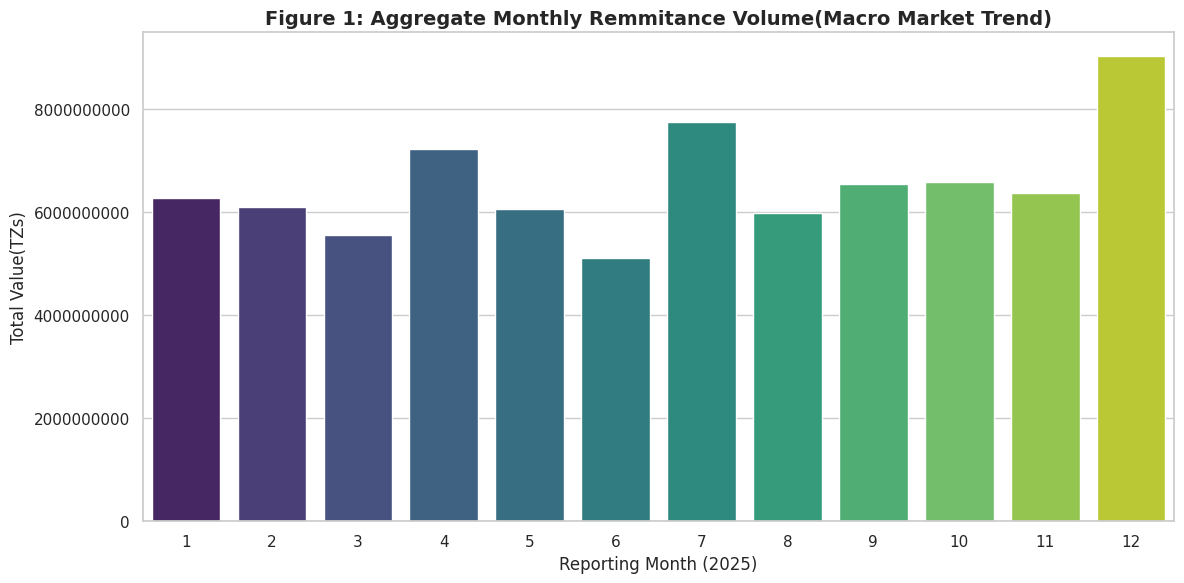

In [ ]:
# 1.2 VISUAL DATA EXPLORATION (EDA)
print("\n Stage 1.2: Generating Visualization for analysis...")
# plot A: Market seasonality chek (total Macro Value by Month)
monthly_market = df.groupby('MONTH')['TOTAL_VALUE'].sum().reset_index()

plt.figure()
sns.barplot(data=monthly_market, x='MONTH',y='TOTAL_VALUE',palette='viridis', legend=False)
plt.title('Figure 1: Aggregate Monthly Remmitance Volume(Macro Market Trend)',fontsize=14,fontweight='bold')
plt.xlabel('Reporting Month (2025)',fontsize=12)
plt.ylabel('Total Value(TZs)',fontsize=12)
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.savefig('eda_market_seasonality.png',dpi=300)
plt.show()

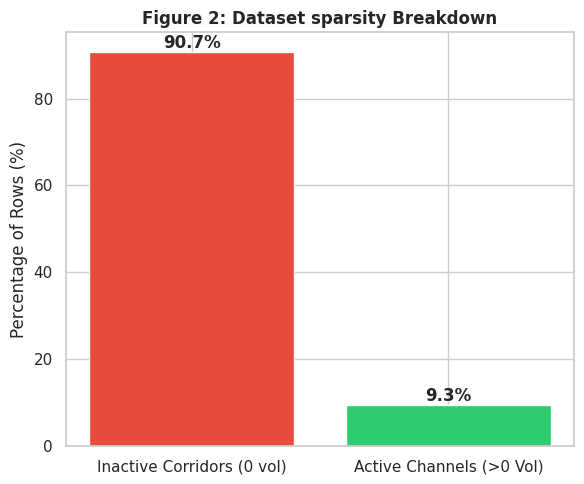

In [ ]:
from matplotlib import colors
# PLOT B the sparsity profile (Visualizing the ocean of zero)
sparsity_check = (df['TOTAL_VALUE'] == 0).value_counts(normalize=True)*100

plt.figure(figsize=(6,5))
plt.bar(['Inactive Corridors (0 vol)','Active Channels (>0 Vol)'],sparsity_check.values,color=['#e74c3c','#2ecc71'])
plt.title('Figure 2: Dataset sparsity Breakdown', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Rows (%)',fontsize=12)
for i, val in enumerate(sparsity_check.values):
  plt.text(i,val + 1, f"{val:.1f}%", ha='center',fontweight='bold')
plt.tight_layout()
plt.savefig('eda_sparsity_check.png',dpi=300)
plt.show()

In [ ]:
# 2.1:ENTER-ENTITY OPERATIONAL RATIOS
print("stage 2: Engineering internalTransactinal ratios...")

# Avarage Transaction values per inflow/outflow to look for hyper-inflation transfers
df['INFLOW_AVG_VAL']= np.where(df['INFLOW_VOLUME'] > 0, df['INFLOW_VALUE'] / df['INFLOW_VOLUME'],0)
df['OUTFLOW_AVG_VAL'] = np.where(df['OUTFLOW_VOLUME'] >0, df['OUTFLOW_VALUE'] / df['OUTFLOW_VOLUME'],0)

# Net liquidity gap within the rporting period
df['NET_FLOW_VALUE'] = df['INFLOW_VALUE'] - df['OUTFLOW_VALUE']

# establish the hurdles flag: 1 for active entity relatioships, 0 for structural zeros
df['IS_ACTIVE'] = np.where(df['TOTAL_VALUE'] > 0,1,0)

# STAGE 2: MONTHLY MARKET SHARE &PEER-GROUP NORMALIZATION
print('Stage 2.2 : computing peer Z-score to neutralize Macro seasonality...')

# step A: compute the total market valume per individual month to creat seasonal baselines
monthly_market_totals = df.groupby('MONTH')['TOTAL_VALUE'].transform('sum')

# step B: Compute the axact market  share a bank-oparator combination holds in that specific month
df['MONTHLY_MARKET_SHARE']=np.where(monthly_market_totals > 0, df['TOTAL_VALUE'] / monthly_market_totals,0)

# step C:  Group by month and compute peer grup mean and standard deviation for active stream
# we filter out zeros during statical window scaling so inactive corridors do not distortthe variance
active_mask = df['IS_ACTIVE'] == 1
df['MONTHLY_VALUE_ZSCORE'] = 0.0 # default initialization for inactive channels
if active_mask.any():
  means = df[active_mask].groupby('MONTH')['TOTAL_VALUE'].transform('mean')
  stds = df[active_mask].groupby('MONTH')['TOTAL_VALUE'].transform('std').replace(0,1)
  # apply standard normalization
  df.loc[active_mask,'MONTHLY_VALUE_ZSCORE'] = (df.loc[active_mask,'TOTAL_VALUE'] - means) / stds

df.head()


stage 2: Engineering internalTransactinal ratios...
Stage 2.2 : computing peer Z-score to neutralize Macro seasonality...


,INSTITUTIONCODE,REPORTINGDATE,DESCRIPTIONNO,COMPANY,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTFLOW_VALUE,MONTH,TOTAL_VALUE,INFLOW_AVG_VAL,OUTFLOW_AVG_VAL,NET_FLOW_VALUE,IS_ACTIVE,MONTHLY_MARKET_SHARE,MONTHLY_VALUE_ZSCORE
0,Bnk-001,2025-01-31,1,Western Union,3745,2207540409,573,273899340,1,273903085,5.894634e+05,4.780093e+05,1933641069,1,0.043607,0.791256
1,Bnk-001,2025-01-31,2,MoneyGram,1941,1351849159,166,116292545,1,116294486,6.964705e+05,7.005575e+05,1235556614,1,0.018515,-0.313861
2,Bnk-001,2025-01-31,3,Travelex,273,1071463474,22,108098083,1,108098356,3.924775e+06,4.913549e+06,963365391,1,0.017210,-0.371330
3,Bnk-001,2025-01-31,4,UBA Africash,169,71548144,16,8833937,1,8834106,4.233618e+05,5.521211e+05,62714207,1,0.001406,-1.067349
4,Bnk-001,2025-01-31,5,Coinstar,0,0,0,0,1,0,0.000000e+00,0.000000e+00,0,0,0.000000,0.000000


In [ ]:
df.describe()

,REPORTINGDATE,DESCRIPTIONNO,INFLOW_VOLUME,INFLOW_VALUE,OUTFLOW_VOLUME,OUTFLOW_VALUE,MONTH,TOTAL_VALUE,INFLOW_AVG_VAL,OUTFLOW_AVG_VAL,NET_FLOW_VALUE,IS_ACTIVE,MONTHLY_MARKET_SHARE,MONTHLY_VALUE_ZSCORE
count,5040,5040.000000,5040.000000,5.040000e+03,5040.000000,5.040000e+03,5040.000000,5.040000e+03,5.040000e+03,5.040000e+03,5.040000e+03,5040.000000,5040.000000,5.040000e+03
mean,2025-07-15 22:00:00,5.500000,87.569444,9.453491e+07,11.724603,1.558992e+07,6.500000,1.559001e+07,2.524435e+05,3.462505e+05,7.894498e+07,0.092857,0.002381,-2.544261e-18
min,2025-01-31 00:00:00,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-1.072536e+00
25%,2025-04-22 12:00:00,3.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,3.750000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
50%,2025-07-15 12:00:00,5.500000,0.000000,0.000000e+00,0.000000,0.000000e+00,6.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
75%,2025-10-07 18:00:00,8.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,9.250000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
max,2025-12-31 00:00:00,10.000000,5676.000000,6.407443e+09,934.000000,1.313219e+09,12.000000,1.313220e+09,1.197251e+07,1.771022e+07,5.094225e+09,1.000000,0.157541,4.620655e+00
std,NaN,2.872566,408.443759,4.257508e+08,57.637492,7.346364e+07,3.452395,7.346387e+07,1.338563e+06,1.899270e+06,3.609371e+08,0.290261,0.010995,3.008224e-01


In [ ]:
# STAGE 2.3: ENCODE CATEGORICAL ENTITIES FOR SUPERVISED LEARNING
print("stage 2.3: Encoding Bank & Vendor categories...")
!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder

stage 2.3: Encoding Bank & Vendor categories...


In [ ]:
le_institution = LabelEncoder()
df['INSTITUTION_ENCODED']=le_institution.fit_transform(df['INSTITUTIONCODE'])
le_company = LabelEncoder()
df['COMPANY_ENCODED'] = le_company.fit_transform(df['COMPANY'])

print("\n---- Feature Engineerin Complete ----")
print(df[['MONTH','TOTAL_VALUE','MONTHLY_MARKET_SHARE','MONTHLY_VALUE_ZSCORE','IS_ACTIVE']].head(10))


---- Feature Engineerin Complete ----
   MONTH  TOTAL_VALUE  MONTHLY_MARKET_SHARE  MONTHLY_VALUE_ZSCORE  IS_ACTIVE
0      1    273903085              0.043607              0.791256          1
1      1    116294486              0.018515             -0.313861          1
2      1    108098356              0.017210             -0.371330          1
3      1      8834106              0.001406             -1.067349          1
4      1            0              0.000000              0.000000          0
5      1            0              0.000000              0.000000          0
6      1     76240938              0.012138             -0.594707          1
7      1            0              0.000000              0.000000          0
8      1    458913959              0.073062              2.088511          1
9      1            0              0.000000              0.000000          0


In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

# --- BEGIN PREPROCESSING REQUIRED FOR IS_ACTIVE --- #
# These lines ensure `df` is properly loaded and engineered
# so that 'IS_ACTIVE' and other columns are available.

print("Re-initializing DataFrame and preprocessing for robust execution...")
df = pd.read_csv('Money_Remittance_transactions_2025.csv')

# Fix header typo
df = df.rename(columns={'OUTLOW_VALUE': 'OUTFLOW_VALUE'})

# Clean string formatting and convert to numeric
num_cols = ['INFLOW_VOLUME', 'INFLOW_VALUE', 'OUTFLOW_VOLUME', 'OUTFLOW_VALUE']
for col in num_cols:
  df[col]= df[col].astype(str).str.replace(',', '', regex=True)
  df[col] = pd.to_numeric(df[col],errors='coerce').fillna(0)

# Standardize date format and parse reporting month
df['REPORTINGDATE'] = pd.to_datetime(df['REPORTINGDATE'],errors='coerce')
df['MONTH'] = df['REPORTINGDATE'].dt.month.fillna(0).astype(int)

# Create a composite total turnover feature
df['TOTAL_VALUE'] = df['INFLOW_VOLUME'] + df['OUTFLOW_VALUE']

# Engineer internal transactional ratios
df['INFLOW_AVG_VAL']= np.where(df['INFLOW_VOLUME'] > 0, df['INFLOW_VALUE'] / df['INFLOW_VOLUME'],0)
df['OUTFLOW_AVG_VAL'] = np.where(df['OUTFLOW_VOLUME'] >0, df['OUTFLOW_VALUE'] / df['OUTFLOW_VOLUME'],0)
df['NET_FLOW_VALUE'] = df['INFLOW_VALUE'] - df['OUTFLOW_VALUE']

# Establish the hurdles flag: 1 for active entity relatioships, 0 for structural zeros
df['IS_ACTIVE'] = np.where(df['TOTAL_VALUE'] > 0,1,0)

# Compute monthly market share and peer-group normalization
monthly_market_totals = df.groupby('MONTH')['TOTAL_VALUE'].transform('sum')
df['MONTHLY_MARKET_SHARE']=np.where(monthly_market_totals > 0, df['TOTAL_VALUE'] / monthly_market_totals,0)

active_mask = df['IS_ACTIVE'] == 1
df['MONTHLY_VALUE_ZSCORE'] = 0.0 # default initialization for inactive channels
if active_mask.any():
  means = df[active_mask].groupby('MONTH')['TOTAL_VALUE'].transform('mean')
  stds = df[active_mask].groupby('MONTH')['TOTAL_VALUE'].transform('std').replace(0,1)
  # apply standard normalization
  df.loc[active_mask,'MONTHLY_VALUE_ZSCORE'] = (df.loc[active_mask,'TOTAL_VALUE'] - means) / stds
# --- END PREPROCESSING REQUIRED FOR IS_ACTIVE --- #


# STAGE 3: UNSUPERVISED OUTLIER ISOLATION AND PSEUDO-LABEL GENERATION
# in this stage we adress the absence of historical lebel deficit by excuting the first phase of out hybrid semi-supervised pipeline

print("stage 3.1: Segmenting active channels for anomaly scoring....")

active_df = df[df['IS_ACTIVE'] == 1].copy()
inactive_df = df[df['IS_ACTIVE'] == 0].copy()

# select the seasonality-neutralized contextual features engineering in stage 2

isloation_features = ['MONTHLY_VALUE_ZSCORE','MONTHLY_MARKET_SHARE','NET_FLOW_VALUE']

# INITIALIZE THE ISOLATION FORST
# we set contamination to 3.5%, isolating the most  severe mulitidimentional outliers

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.035,
    random_state=42
)

# STAGE 3.2: FIT MODEL & GENERATE TARGET PSEUDO-LABELS
print("stage 3.2: Genarating pseudo-labels on active transaction data...")

iso_forest.fit(active_df[isloation_features])
active_predictions = iso_forest.predict(active_df[isloation_features])

# convert states to to abinary target vector: 1, for suspecious Anomly,0 for Compliant
active_df['FRAUD_LABEL'] = np.where(active_predictions == -1,1,0)

# extract raw coontinuous anaomlay scores(lower score indicate deeper tree islation)
active_df['ANOMALY_SCORE'] = iso_forest.decision_function(active_df[isloation_features])

# Assign normal compliance status (0) to all inactive structural zero channels
inactive_df['FRAUD_LABEL'] = 0
inactive_df['ANOMALY_SCORE'] = 1.0

# STAGE 3.3: RECOMBINE DATSET
print("stage 3.3: Re_assemblisng final baselinecompliance dataframe...")

final_df = pd.concat([active_df, inactive_df]).sort_index()

# print("\n---- outlier isolation complete ---")
print(final_df.head(20))

Re-initializing DataFrame and preprocessing for robust execution...
stage 3.1: Segmenting active channels for anomaly scoring....
stage 3.2: Genarating pseudo-labels on active transaction data...
stage 3.3: Re_assemblisng final baselinecompliance dataframe...
   INSTITUTIONCODE REPORTINGDATE  DESCRIPTIONNO  \
0          Bnk-001    2025-01-31              1   
1          Bnk-001    2025-01-31              2   
2          Bnk-001    2025-01-31              3   
3          Bnk-001    2025-01-31              4   
4          Bnk-001    2025-01-31              5   
5          Bnk-001    2025-01-31              6   
6          Bnk-001    2025-01-31              7   
7          Bnk-001    2025-01-31              8   
8          Bnk-001    2025-01-31              9   
9          Bnk-001    2025-01-31             10   
10         Bnk-002    2025-01-31              1   
11         Bnk-002    2025-01-31              2   
12         Bnk-002    2025-01-31              3   
13         Bnk-002    2025

In [ ]:
print(final_df['FRAUD_LABEL'].value_counts())


FRAUD_LABEL
0    5023
1      17
Name: count, dtype: int64


### Computing Ensemble Anomaly Scores and Votes

To analyze fraud yield based on different `ENSEMBLE_VOTES` thresholds, we need to first compute these scores. This cell replicates the multi-seed Isolation Forest ensemble logic from your `pipe_line.py` to generate `RAW_ANOMALY_SCORE`, `ENSEMBLE_VOTES`, and `ANOMALY_CONFIDENCE` for each transaction.

This will allow us to assess how different gating criteria would have impacted the pseudo-label generation for your XGBoost model.

In [10]:
from sklearn.ensemble import IsolationForest

print("\n[ENSEMBLE COMPUTATION] Starting multi-seed Isolation Forest ensemble...")

# Define preliminary features as used in your pipe_line.py and previous notebook cells
preliminary_features = ['MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE']

# Filter for active records for fitting the Isolation Forest
df_active_train_ensemble = df[df["IS_ACTIVE"] == 1].copy()

# Define adaptive contamination (using the same fixed value as in the notebook's single IF for now)
# In a real MLOps pipeline, this might be dynamically computed.
adaptive_contamination = 0.035

print(f"[ENSEMBLE] Adaptive contamination = {adaptive_contamination:.4f}")

# Multi-Seed Isolation Forest Ensemble settings
seeds = [42, 101, 202, 303, 404]
ensemble_models = {}

# Initialize a matrix to store anomaly scores from each seed for all records in the full df
all_scores_matrix = np.zeros((len(df), len(seeds)))

# Handle empty active training set case
if df_active_train_ensemble.empty:
    print("[WARNING] df_active_train_ensemble is empty. Defaulting ensemble scores to zero.")
    df['RAW_ANOMALY_SCORE'] = 0.0
    df['MEDIAN_ANOMALY_SCORE'] = 0.0
    df['SD_ANOMALY_SCORE'] = 0.0
    df['ENSEMBLE_VOTES'] = 0
    df['ANOMALY_CONFIDENCE'] = 0.0
else:
    for idx, seed in enumerate(seeds):
        iso = IsolationForest(
            n_estimators=200,
            contamination=adaptive_contamination,
            random_state=seed,
            max_samples="auto",
            bootstrap=True,
            n_jobs=-1
        )

        # Fit on active training data
        iso.fit(df_active_train_ensemble[preliminary_features].fillna(0.0))
        ensemble_models[f"seed_{seed}"] = iso

        # Score all data points (active and inactive) from the main df
        all_scores_matrix[:, idx] = -iso.score_samples(df[preliminary_features].fillna(0.0))

    # Calculate ensemble metrics
    df['RAW_ANOMALY_SCORE'] = np.mean(all_scores_matrix, axis=1) # Corresponds to MEAN_ANOMALY_SCORE
    df['MEDIAN_ANOMALY_SCORE'] = np.median(all_scores_matrix, axis=1)
    df['SD_ANOMALY_SCORE'] = np.std(all_scores_matrix, axis=1)

    # Consensus Voting (each Isolation Forest votes if score is above its own 97th percentile)
    vote_matrix = np.zeros_like(all_scores_matrix)
    for i in range(len(seeds)):
        # Ensure we only calculate percentile from actual scores, not just zeros if df_active_train was tiny
        relevant_scores = all_scores_matrix[:, i]
        if len(relevant_scores) > 0:
            threshold = np.percentile(relevant_scores, 97)
            vote_matrix[:, i] = (relevant_scores >= threshold).astype(int)

    df['ENSEMBLE_VOTES'] = vote_matrix.sum(axis=1)

    # Calculate Anomaly Confidence
    max_sd = df["SD_ANOMALY_SCORE"].max()
    if max_sd == 0 or np.isnan(max_sd):
        max_sd = 1.0
    stability_score = (1.0 - (df["SD_ANOMALY_SCORE"] / max_sd))
    vote_score = (df["ENSEMBLE_VOTES"] / len(seeds))
    df['ANOMALY_CONFIDENCE'] = (0.4 * stability_score + 0.6 * vote_score)

print("[ENSEMBLE COMPUTATION] Multi-seed Isolation Forest ensemble completed.")

# Display summary of new ensemble scores for active records
print("\nEnsemble Score Summary (Active Records):")
display(df[df['IS_ACTIVE'] == 1][['RAW_ANOMALY_SCORE', 'ENSEMBLE_VOTES', 'ANOMALY_CONFIDENCE']].describe())


[ENSEMBLE COMPUTATION] Starting multi-seed Isolation Forest ensemble...
[ENSEMBLE] Adaptive contamination = 0.0350
[ENSEMBLE COMPUTATION] Multi-seed Isolation Forest ensemble completed.

Ensemble Score Summary (Active Records):


,RAW_ANOMALY_SCORE,ENSEMBLE_VOTES,ANOMALY_CONFIDENCE
count,468.000000,468.000000,468.000000
mean,0.471365,0.623932,0.270655
std,0.073307,1.600195,0.195009
min,0.395182,0.000000,0.000000
25%,0.421812,0.000000,0.170483
50%,0.448103,0.000000,0.218610
75%,0.493601,0.000000,0.269683
max,0.781785,5.000000,0.913033


### Fraud Yield Analysis for Different `ENSEMBLE_VOTES` Thresholds

Now that we have computed `ENSEMBLE_VOTES` for each record, we can calculate the fraud yield percentage for various thresholds. This analysis will help you understand how relaxing or tightening the `ENSEMBLE_VOTES` condition (part of your `fraud_condition` in `pipe_line.py`) impacts the number of records considered as high-confidence fraud. This is crucial for addressing the 'Insufficient variance' issue.

In [11]:
print("\n[FRAUD YIELD ANALYSIS] Calculating fraud yield for different ENSEMBLE_VOTES thresholds...")

# Filter for active records, as pseudo-labeling and gating apply to these
active_records_ensemble_df = df[df['IS_ACTIVE'] == 1].copy()

total_active_records = len(active_records_ensemble_df)

if total_active_records == 0:
    print("No active records found for analysis.")
else:
    print(f"Total Active Records: {total_active_records}")
    results = []
    # Iterate through possible ENSEMBLE_VOTES thresholds
    # The number of seeds is 5, so votes can range from 0 to 5
    for threshold in range(0, len(seeds) + 1):
        # Apply a simplified fraud condition using only ENSEMBLE_VOTES
        # In pipe_line.py, other conditions like RAW_ANOMALY_SCORE and RECONSTRUCTION_ERROR are also used.
        # For this exercise, we focus on the impact of ENSEMBLE_VOTES.
        fraud_yield_mask = (active_records_ensemble_df['ENSEMBLE_VOTES'] >= threshold)
        fraud_yield_count = fraud_yield_mask.sum()

        fraud_yield_percentage = (fraud_yield_count / total_active_records) * 100

        results.append({
            'ENSEMBLE_VOTES Threshold': threshold,
            'Fraud Records Count': fraud_yield_count,
            'Fraud Yield Percentage': f'{fraud_yield_percentage:.2f}%'
        })

    results_df = pd.DataFrame(results)
    display(results_df)

    print("\n[FRAUD YIELD ANALYSIS] Analysis complete. Consider these yields when adjusting your pipeline's gating criteria.")


[FRAUD YIELD ANALYSIS] Calculating fraud yield for different ENSEMBLE_VOTES thresholds...
Total Active Records: 468


,ENSEMBLE_VOTES Threshold,Fraud Records Count,Fraud Yield Percentage
0,0,468,100.00%
1,1,67,14.32%
2,2,62,13.25%
3,3,59,12.61%
4,4,53,11.32%
5,5,51,10.90%



[FRAUD YIELD ANALYSIS] Analysis complete. Consider these yields when adjusting your pipeline's gating criteria.


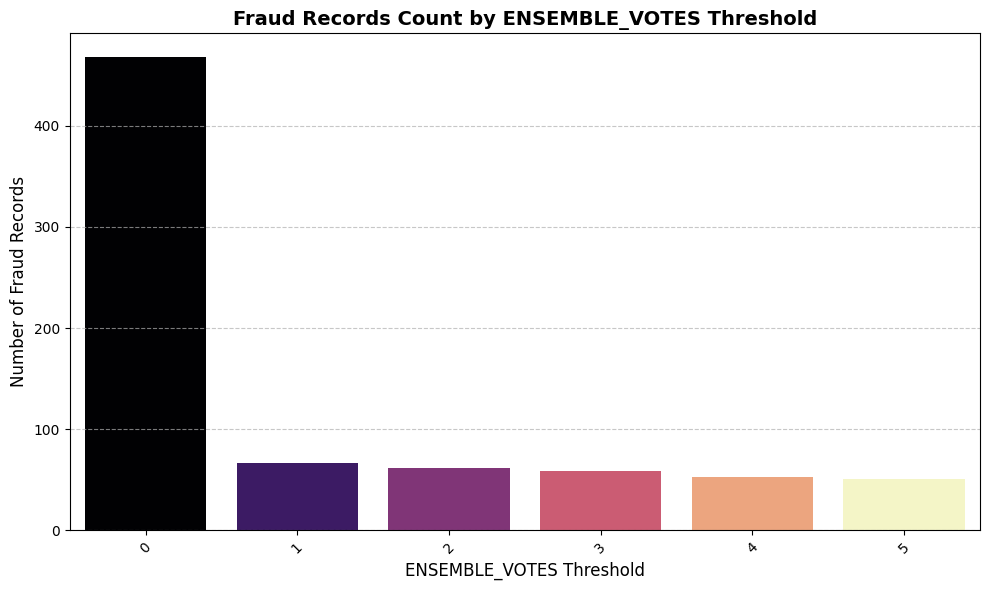

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='ENSEMBLE_VOTES Threshold', y='Fraud Records Count', data=results_df, palette='magma', hue='ENSEMBLE_VOTES Threshold', legend=False)
plt.title('Fraud Records Count by ENSEMBLE_VOTES Threshold', fontsize=14, fontweight='bold')
plt.xlabel('ENSEMBLE_VOTES Threshold', fontsize=12)
plt.ylabel('Number of Fraud Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

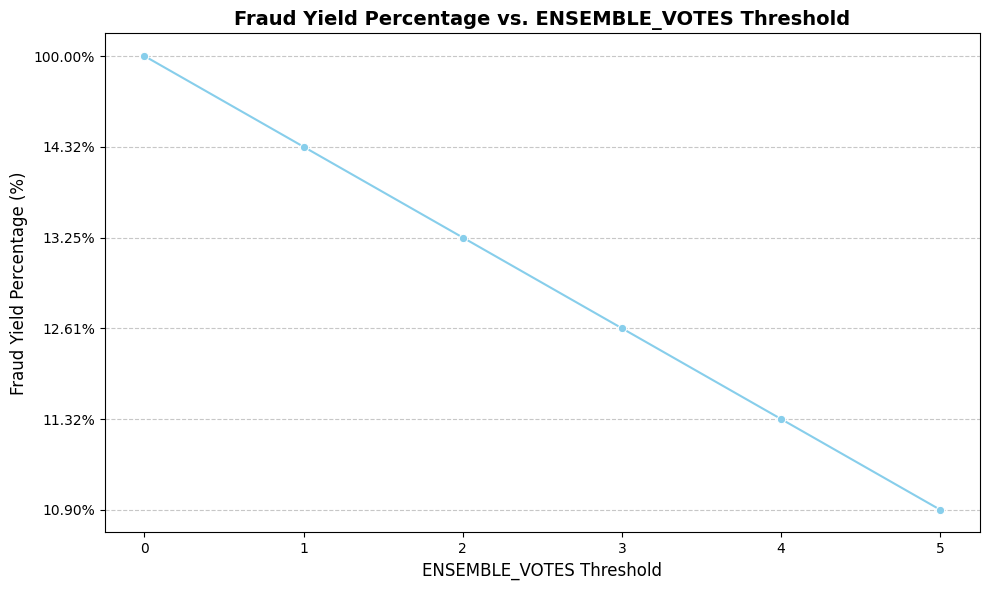

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='ENSEMBLE_VOTES Threshold', y='Fraud Yield Percentage', data=results_df.assign(Fraud_Yield_Percentage_Float=results_df['Fraud Yield Percentage'].str.rstrip('%').astype(float)), marker='o', color='skyblue')
plt.title('Fraud Yield Percentage vs. ENSEMBLE_VOTES Threshold', fontsize=14, fontweight='bold')
plt.xlabel('ENSEMBLE_VOTES Threshold', fontsize=12)
plt.ylabel('Fraud Yield Percentage (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(results_df['ENSEMBLE_VOTES Threshold'].unique())
plt.tight_layout()
plt.show()

### Visualizing `ANOMALY_SCORE` for Gating Threshold

Below, we visualize the distribution of the `ANOMALY_SCORE` calculated in the notebook. This score indicates how anomalous a transaction is, with lower values representing higher anomaly. We'll also highlight the scores corresponding to transactions currently labeled as fraud (`FRAUD_LABEL=1`) to identify potential thresholds.

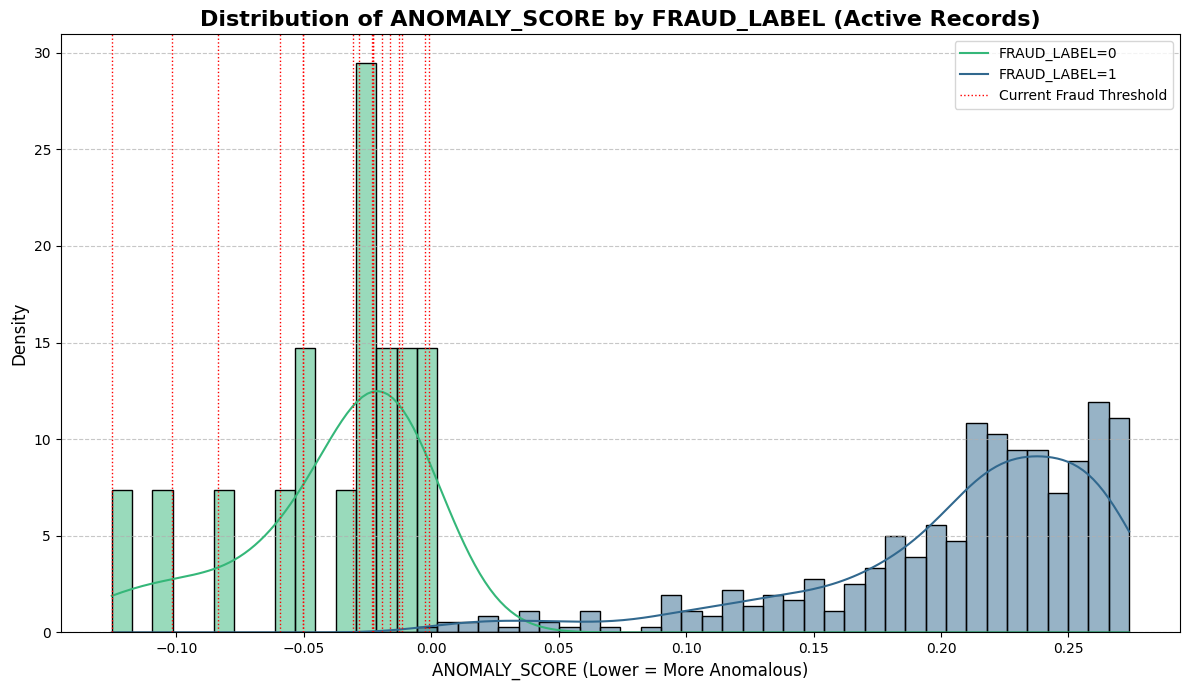

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter for active records, as inactive records have a default ANOMALY_SCORE of 1.0 which would skew the plot
active_records_df = final_df[final_df['IS_ACTIVE'] == 1].copy()

plt.figure(figsize=(12, 7))
sns.histplot(
    data=active_records_df,
    x='ANOMALY_SCORE',
    hue='FRAUD_LABEL', # Use FRAUD_LABEL to distinguish between normal and anomalous scores
    kde=True, # Add Kernel Density Estimate to see smoothed distribution
    palette='viridis', # Choose a color palette
    common_norm=False, # Normalize histograms independently
    stat='density', # Show density instead of counts
    bins=50 # More bins for a detailed view
)

plt.title('Distribution of ANOMALY_SCORE by FRAUD_LABEL (Active Records)', fontsize=16, fontweight='bold')
plt.xlabel('ANOMALY_SCORE (Lower = More Anomalous)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlight the scores of fraud cases more clearly
fraud_scores = active_records_df[active_records_df['FRAUD_LABEL'] == 1]['ANOMALY_SCORE']
if not fraud_scores.empty:
    for score in fraud_scores:
        plt.axvline(x=score, color='red', linestyle=':', linewidth=1, label=f'Fraud Score ({score:.2f})' if score == fraud_scores.iloc[0] else "")
    plt.legend(['FRAUD_LABEL=0', 'FRAUD_LABEL=1', 'Current Fraud Threshold'], loc='upper right')
else:
    plt.legend(['FRAUD_LABEL=0', 'FRAUD_LABEL=1'], loc='upper right')

plt.tight_layout()
plt.show()

### Interpreting the `ANOMALY_SCORE` Distribution

The plot above shows the distribution of `ANOMALY_SCORE` for both normal (FRAUD_LABEL=0) and anomalous (FRAUD_LABEL=1) transactions within your active dataset. Remember that for the Isolation Forest, lower (more negative) `ANOMALY_SCORE` values indicate higher anomaly.

From this visualization, you can observe:

*   **Separation:** How well the `ANOMALY_SCORE` separates the two classes (compliant vs. anomalous). Ideally, fraud samples should cluster towards the lower (more negative) end of the score spectrum.
*   **Threshold Identification:** The vertical red lines mark the `ANOMALY_SCORE` values that were identified as anomalies by the Isolation Forest. You can look at the density curves to visually identify a score threshold where the density of fraud samples is significantly higher than that of normal samples. This visual inspection can help in refining your `fraud_condition` thresholds in `pipe_line.py`.
*   **Overlap:** If there's significant overlap between the distributions of `FRAUD_LABEL=0` and `FRAUD_LABEL=1`, it suggests that the `ANOMALY_SCORE` alone might not be sufficiently discriminatory, or that the current Isolation Forest parameters (like `contamination`) might need tuning.

To make your `fraud_condition` in `pipe_line.py` less restrictive (to capture more potential fraud, especially given the current issue of 'Insufficient variance'), you might consider adjusting the percentile cut-off for `RAW_ANOMALY_SCORE` to a less extreme percentile (e.g., 90th or 95th instead of 99th, depending on the distribution) or relaxing the `ENSEMBLE_VOTES` threshold. The goal is to ensure enough positive samples for your XGBoost model to train effectively.

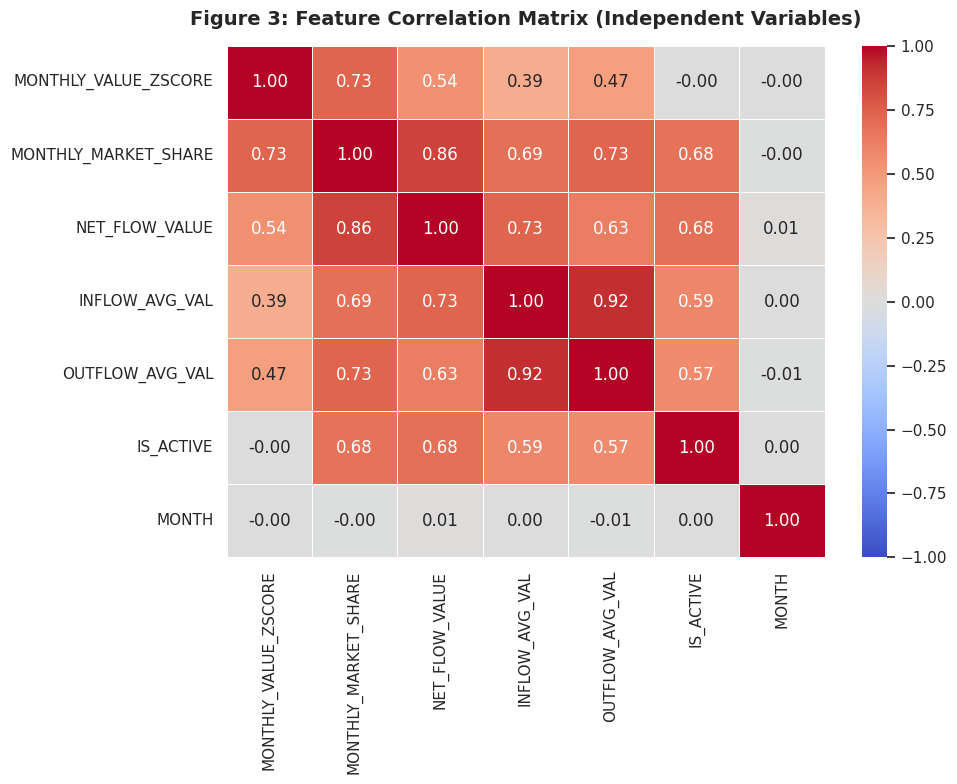

In [ ]:
# Define the independent variables (features) and dependent variable (target)
features_to_analyze = [
    'MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE',
    'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL', 'IS_ACTIVE', 'MONTH'
]

# VISUALIZATION 4.1: CORRELATION HEATMAP (FEATURE INTER-RELATIONSHIPS)
plt.figure(figsize=(10, 8))
corr_matrix = final_df[features_to_analyze].corr()
# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Figure 3: Feature Correlation Matrix (Independent Variables)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('xgb_feature_correlation.png', dpi=300)
plt.show()



Generating Feature vs. Target Distribution Plots...


/tmp/ipykernel_12896/3474461622.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=final_df[final_df['IS_ACTIVE']==1], x='FRAUD_LABEL', y='MONTHLY_VALUE_ZSCORE', palette='Set2',legend=False)
/tmp/ipykernel_12896/3474461622.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=final_df[final_df['IS_ACTIVE']==1], x='FRAUD_LABEL', y='MONTHLY_MARKET_SHARE', palette='Set2',legend=False)


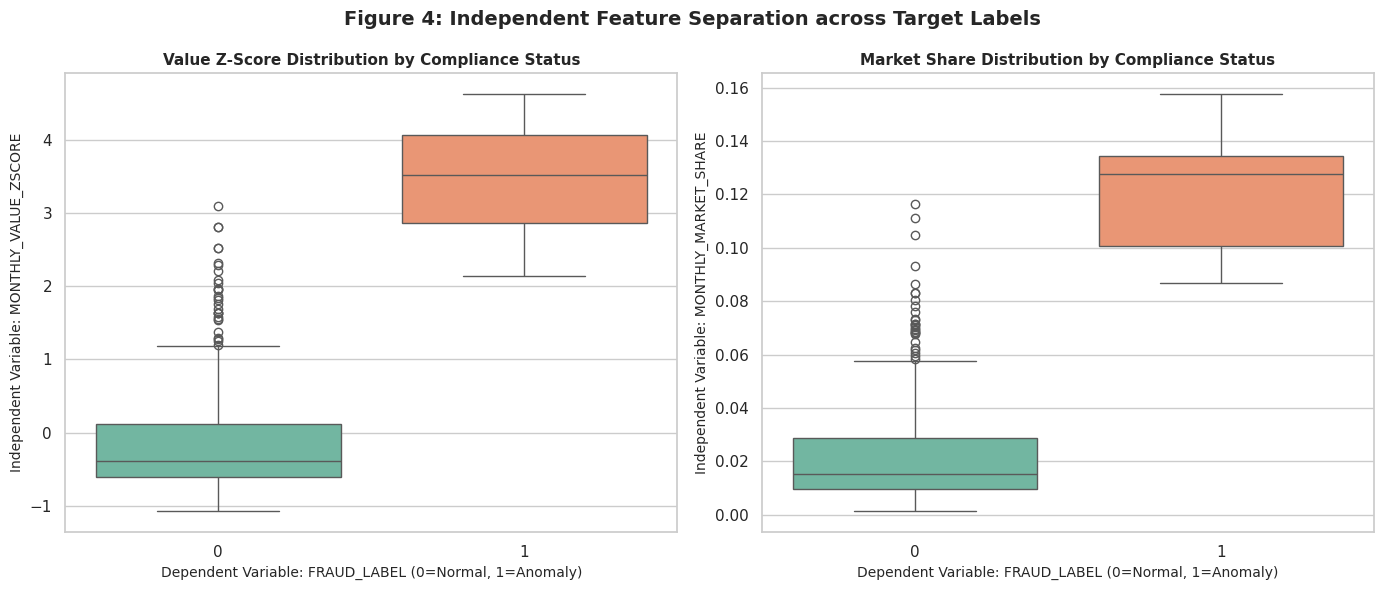

In [ ]:
# VISUALIZATION 4.2: INDEPENDENT VS DEPENDENT VARIABLE RELATIONSHIP

print("\nGenerating Feature vs. Target Distribution Plots...")

# Let's plot how our main independent variable (Z-SCORE) separates the dependent variable (FRAUD_LABEL)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for Monthly Value Z-Score vs Fraud Label
sns.boxplot(ax=axes[0], data=final_df[final_df['IS_ACTIVE']==1], x='FRAUD_LABEL', y='MONTHLY_VALUE_ZSCORE', palette='Set2',legend=False)
axes[0].set_title('Value Z-Score Distribution by Compliance Status', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Dependent Variable: FRAUD_LABEL (0=Normal, 1=Anomaly)', fontsize=10)
axes[0].set_ylabel('Independent Variable: MONTHLY_VALUE_ZSCORE', fontsize=10)
# Boxplot for Monthly Market Share vs Fraud Label
sns.boxplot(ax=axes[1], data=final_df[final_df['IS_ACTIVE']==1], x='FRAUD_LABEL', y='MONTHLY_MARKET_SHARE', palette='Set2',legend=False)
axes[1].set_title('Market Share Distribution by Compliance Status', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Dependent Variable: FRAUD_LABEL (0=Normal, 1=Anomaly)', fontsize=10)
axes[1].set_ylabel('Independent Variable: MONTHLY_MARKET_SHARE', fontsize=10)

plt.suptitle('Figure 4: Independent Feature Separation across Target Labels', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('independent_vs_dependent_relationship.png', dpi=300)
plt.show()

### PCA for Anomaly Detection: Reconstruction Error

Principal Component Analysis (PCA) can be used as an anomaly detection technique by leveraging the concept of reconstruction error. The idea is that a PCA model trained on 'normal' data will be able to reconstruct normal instances with high accuracy (low error). However, when presented with an anomalous instance, the PCA model will struggle to reconstruct it accurately, resulting in a high reconstruction error.

Here, we will apply PCA to the same `isloation_features` used for the Isolation Forest, calculate the reconstruction error, and visualize how this error distinguishes between normal and pseudo-fraudulent records (based on the `FRAUD_LABEL` from the Isolation Forest).

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("\n[PCA for Anomaly Detection] Applying PCA and calculating reconstruction error...")

# Prepare data for PCA
# Use only active records for fitting PCA, as anomalies are expected to be within active transactions
# and we want PCA to learn the normal patterns of active transactions.
active_df_pca = final_df[final_df['IS_ACTIVE'] == 1].copy()

# Select features used for Isolation Forest, as these are the core anomaly detection features
pca_features = ['MONTHLY_VALUE_ZSCORE','MONTHLY_MARKET_SHARE','NET_FLOW_VALUE']

X_pca = active_df_pca[pca_features].fillna(0.0) # Handle potential NaNs before scaling

# Standardize the features - crucial for PCA
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

# Determine the number of components. Often, a few components capture most variance.
# For anomaly detection, we might choose a number of components that captures most of the variance
# of the normal data, or a fixed small number, so anomalies stand out in the residual.
# Let's start with 2 components for visualization, or a number that explains 95% variance.
# For reconstruction error, we often choose `n_components` such that some variance is left out to detect anomalies.
# Let's try 2 components for this example, which is less than the number of features (3).

n_components = 2 # Or use `pca = PCA(n_components=0.95)` to retain 95% variance
pca = PCA(n_components=n_components, random_state=42)

# Fit PCA on scaled active data
pca.fit(X_pca_scaled)

# Transform data to principal components space
X_pca_transformed = pca.transform(X_pca_scaled)

# Reconstruct the data from the reduced dimensions
X_pca_reconstructed = pca.inverse_transform(X_pca_transformed)

# Calculate the reconstruction error (Mean Squared Error)
# The error is the difference between the original scaled data and its reconstruction
reconstruction_errors = np.mean(np.square(X_pca_scaled - X_pca_reconstructed), axis=1)

# Add reconstruction error to the active_df_pca
active_df_pca['RECONSTRUCTION_ERROR'] = reconstruction_errors

# Merge reconstruction errors back into the main DataFrame (final_df) for all records,
# assigning 0 error to inactive records or NaN/a high value if preferred for comparison.
# For simplicity, we'll align by index.
final_df = final_df.merge(
    active_df_pca[['RECONSTRUCTION_ERROR']],
    left_index=True, right_index=True, how='left'
)

# Fill NaN reconstruction errors for inactive records (where IS_ACTIVE == 0) with 0 or a distinguishing value
final_df['RECONSTRUCTION_ERROR'] = final_df['RECONSTRUCTION_ERROR'].fillna(0.0) # Or another suitable default

print("[PCA for Anomaly Detection] Reconstruction error calculation complete.")

# Display summary of reconstruction errors for active records
print("\nReconstruction Error Summary (Active Records):")
display(final_df[final_df['IS_ACTIVE'] == 1]['RECONSTRUCTION_ERROR'].describe())


[PCA for Anomaly Detection] Applying PCA and calculating reconstruction error...
[PCA for Anomaly Detection] Reconstruction error calculation complete.

Reconstruction Error Summary (Active Records):


,RECONSTRUCTION_ERROR
count,4.680000e+02
mean,1.454195e-03
std,4.871187e-03
min,7.479716e-13
25%,2.108957e-05
50%,1.970204e-04
75%,7.929182e-04
max,5.286716e-02


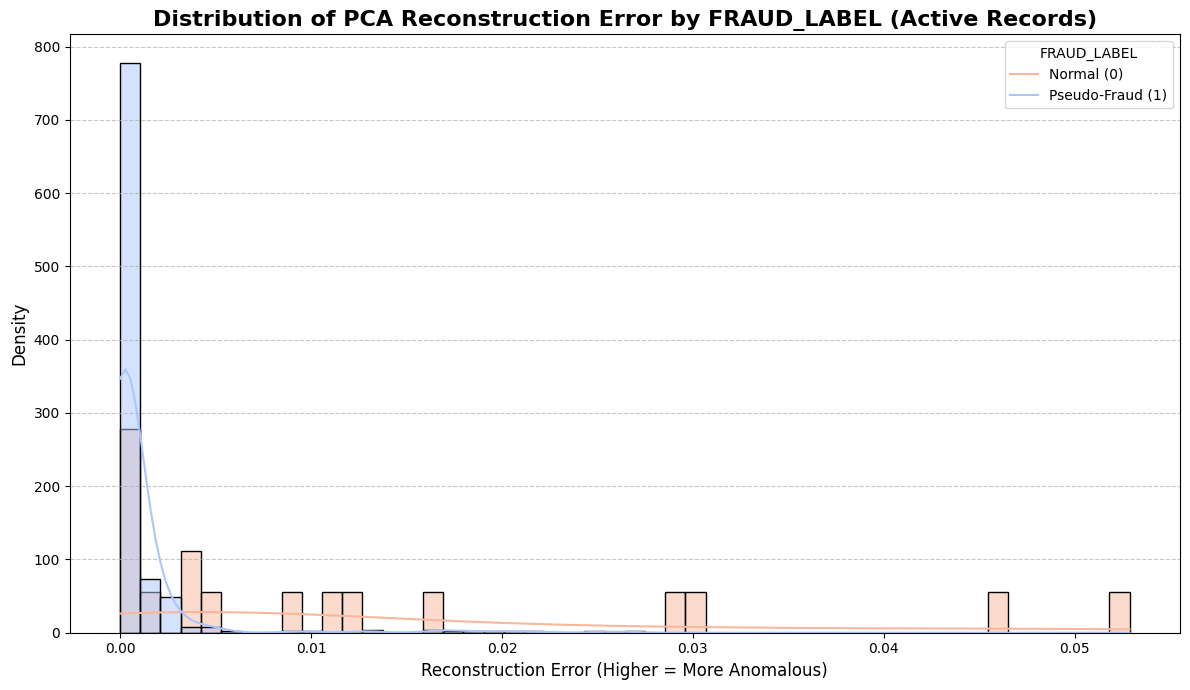

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for active records for visualization
active_records_with_pca = final_df[final_df['IS_ACTIVE'] == 1].copy()

plt.figure(figsize=(12, 7))
sns.histplot(
    data=active_records_with_pca,
    x='RECONSTRUCTION_ERROR',
    hue='FRAUD_LABEL', # Use FRAUD_LABEL to distinguish between normal and anomalous
    kde=True,
    palette='coolwarm',
    common_norm=False,
    stat='density',
    bins=50
)

plt.title('Distribution of PCA Reconstruction Error by FRAUD_LABEL (Active Records)', fontsize=16, fontweight='bold')
plt.xlabel('Reconstruction Error (Higher = More Anomalous)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='FRAUD_LABEL', labels=['Normal (0)', 'Pseudo-Fraud (1)'])
plt.tight_layout()
plt.show()

### Interpreting the PCA Reconstruction Error Distribution

The plot above displays the distribution of PCA reconstruction errors for your active dataset, segmented by the `FRAUD_LABEL` (pseudo-fraudulent or normal) derived from the Isolation Forest. Higher reconstruction error values suggest that the data point is less consistent with the patterns learned by PCA from the majority of the data, thus indicating a higher likelihood of being anomalous.

From this visualization, you can observe:

*   **Separation:** How well the reconstruction error separates the two classes. Ideally, pseudo-fraud samples should exhibit significantly higher reconstruction errors compared to normal samples.
*   **Threshold Identification:** You can visually identify potential thresholds for reconstruction error that could be used in your `fraud_condition` within `pipe_line.py`. A threshold that effectively separates the higher-error anomalies from the lower-error normal records would be beneficial.
*   **Overlap:** The degree of overlap between the distributions of normal and pseudo-fraudulent records indicates the effectiveness of reconstruction error alone in identifying these anomalies. If there is substantial overlap, combining this feature with other anomaly scores (like `RAW_ANOMALY_SCORE` and `ENSEMBLE_VOTES`) becomes even more critical.

This analysis confirms that reconstruction error can serve as a valuable feature in your multi-criteria gating matrix for identifying anomalies. By incorporating this into your `fraud_condition` with appropriate thresholds, you can further refine your pseudo-labeling process.

### Correlation between Reconstruction Error and Anomaly Score

To understand how these two anomaly detection metrics (`RECONSTRUCTION_ERROR` from PCA and `ANOMALY_SCORE` from Isolation Forest) relate to each other, we will calculate their Pearson correlation coefficient and visualize their relationship with a scatter plot. A strong positive correlation would suggest that both metrics tend to identify similar types of anomalies, while a weaker correlation might indicate they capture different facets of anomalous behavior.

Pearson Correlation between RECONSTRUCTION_ERROR and ANOMALY_SCORE (Active Records): -0.5672


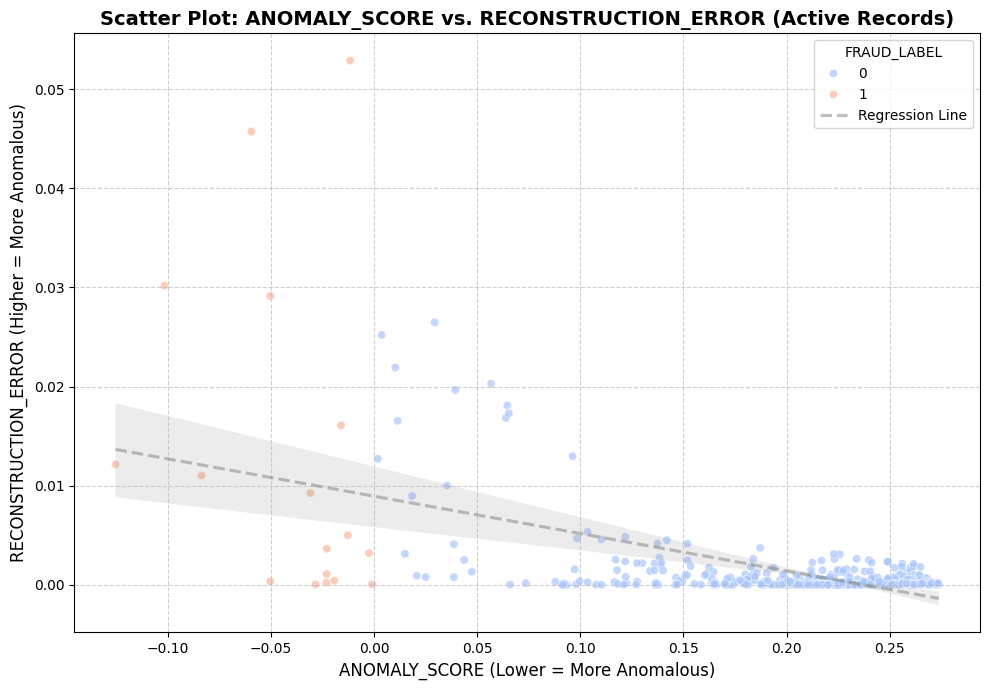

In [17]:
# Filter for active records, as both scores are primarily relevant for these
active_df_for_corr = final_df[final_df['IS_ACTIVE'] == 1].copy()

# Calculate the Pearson correlation between RECONSTRUCTION_ERROR and ANOMALY_SCORE
correlation = active_df_for_corr['RECONSTRUCTION_ERROR'].corr(active_df_for_corr['ANOMALY_SCORE'])

print(f"Pearson Correlation between RECONSTRUCTION_ERROR and ANOMALY_SCORE (Active Records): {correlation:.4f}")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=active_df_for_corr,
    x='ANOMALY_SCORE',
    y='RECONSTRUCTION_ERROR',
    hue='FRAUD_LABEL', # Color points by FRAUD_LABEL to see if anomalies cluster
    palette='coolwarm',
    alpha=0.7
)
sns.regplot(
    data=active_df_for_corr,
    x='ANOMALY_SCORE',
    y='RECONSTRUCTION_ERROR',
    scatter=False, # Don't plot scatter points again
    color='gray',
    line_kws={'linestyle':'--', 'alpha':0.5},
    label='Regression Line'
)

plt.title('Scatter Plot: ANOMALY_SCORE vs. RECONSTRUCTION_ERROR (Active Records)', fontsize=14, fontweight='bold')
plt.xlabel('ANOMALY_SCORE (Lower = More Anomalous)', fontsize=12)
plt.ylabel('RECONSTRUCTION_ERROR (Higher = More Anomalous)', fontsize=12)
plt.legend(title='FRAUD_LABEL')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpreting the Correlation Plot

The scatter plot above visualizes the relationship between the `ANOMALY_SCORE` (from Isolation Forest) and the `RECONSTRUCTION_ERROR` (from PCA) for active records. The Pearson correlation coefficient quantifies this linear relationship.

*   **Correlation Value:**
    *   A correlation close to `1` would suggest a strong positive linear relationship, meaning both metrics tend to increase or decrease together. If `ANOMALY_SCORE` (lower is more anomalous) and `RECONSTRUCTION_ERROR` (higher is more anomalous) both point to the same type of anomaly, you might expect a negative correlation in their raw values, but since `ANOMALY_SCORE` is often inverted for interpretability (higher score = more anomalous), a positive correlation would then indicate alignment.
    *   A correlation near `0` indicates little to no linear relationship, suggesting that these two anomaly detection techniques might be capturing different aspects or types of anomalies.

*   **Scatter Plot Observations:**
    *   **Clustering:** Observe if points colored as `FRAUD_LABEL=1` (pseudo-fraud) tend to cluster in specific regions of the plot (e.g., high reconstruction error and low anomaly score).
    *   **Linear Trend:** The regression line helps to visualize any linear trend between the two variables.
    *   **Dispersion:** The spread of the points around the regression line indicates the strength of the relationship. A tighter spread implies a stronger correlation.

This analysis helps determine if `RECONSTRUCTION_ERROR` provides independent information compared to `ANOMALY_SCORE`, or if they largely overlap in their anomaly detection capabilities. This insight is useful when deciding how to combine these metrics in your `fraud_condition` for a more robust pseudo-labeling strategy.

### Calculating Optimal Threshold for `RECONSTRUCTION_ERROR`

To find an optimal threshold for `RECONSTRUCTION_ERROR` that balances precision and recall, we will iterate through a range of possible values for active records and calculate the F1-score at each point. The F1-score is particularly useful in imbalanced datasets as it considers both false positives and false negatives. We will aim to maximize this score to find a balanced threshold.

Optimal RECONSTRUCTION_ERROR Threshold (max F1-score): 0.005012
  Precision at optimal threshold: 39.13%
  Recall at optimal threshold: 52.94%
  F1-score at optimal threshold: 45.00%


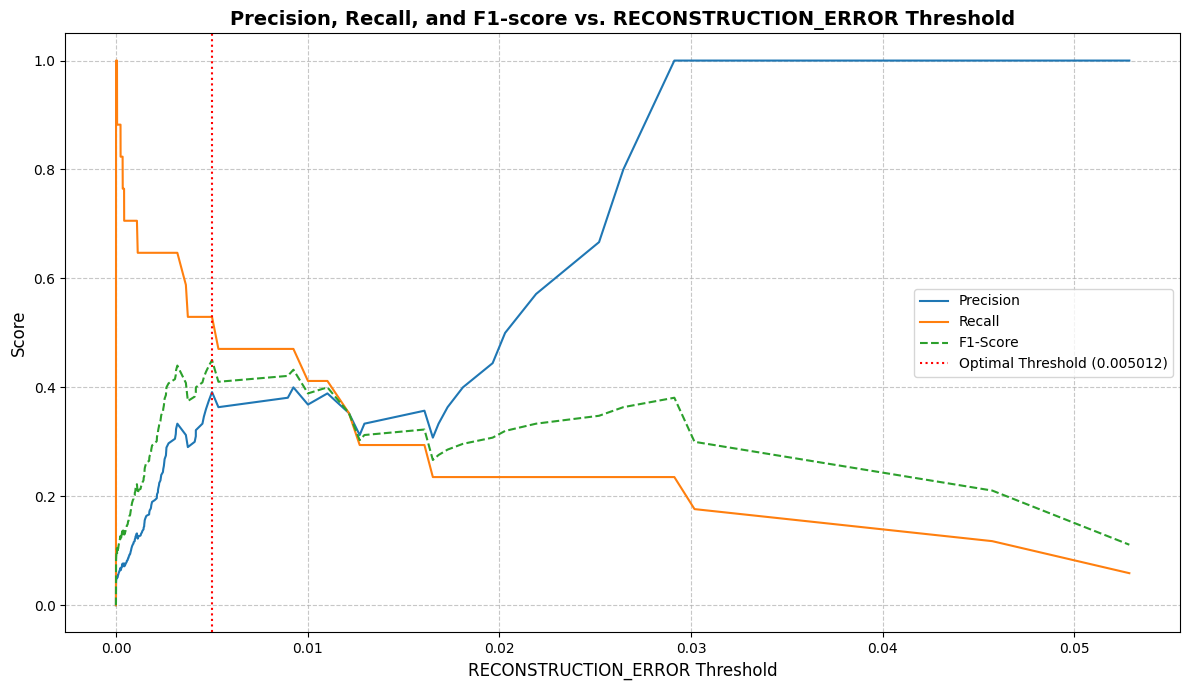

In [18]:
from sklearn.metrics import precision_recall_fscore_support

# Filter for active records
active_df_metrics = final_df[final_df['IS_ACTIVE'] == 1].copy()

# Ensure there are pseudo-fraud labels to evaluate against
if active_df_metrics['FRAUD_LABEL'].sum() == 0:
    print("No pseudo-fraud labels (FRAUD_LABEL = 1) found in active records. Cannot calculate optimal RECONSTRUCTION_ERROR threshold.")
else:
    threshold_metrics = []
    # Sort unique reconstruction errors to iterate through potential thresholds
    unique_reconstruction_errors = np.sort(active_df_metrics['RECONSTRUCTION_ERROR'].unique())

    # Iterate through potential thresholds. Higher RECONSTRUCTION_ERROR indicates anomaly.
    for threshold in unique_reconstruction_errors:
        # Predict anomalies based on the current threshold
        predictions = (active_df_metrics['RECONSTRUCTION_ERROR'] >= threshold).astype(int)

        # Calculate metrics if both classes are present in predictions and actuals
        if np.unique(predictions).size > 1 and np.unique(active_df_metrics['FRAUD_LABEL']).size > 1:
            precision, recall, fscore, _ = precision_recall_fscore_support(
                active_df_metrics['FRAUD_LABEL'], predictions, average='binary', pos_label=1, zero_division=0
            )
        else:
            # Handle cases where predictions or actuals don't have both classes
            precision = 0.0
            recall = 0.0
            fscore = 0.0

        threshold_metrics.append({'threshold': threshold, 'precision': precision, 'recall': recall, 'fscore': fscore})

    metrics_df_re = pd.DataFrame(threshold_metrics)

    # Find the threshold that maximizes F1-score
    optimal_re_threshold_row = metrics_df_re.loc[metrics_df_re['fscore'].idxmax()]
    optimal_re_threshold = optimal_re_threshold_row['threshold']

    print(f"Optimal RECONSTRUCTION_ERROR Threshold (max F1-score): {optimal_re_threshold:.6f}")
    print(f"  Precision at optimal threshold: {optimal_re_threshold_row['precision']:.2%}")
    print(f"  Recall at optimal threshold: {optimal_re_threshold_row['recall']:.2%}")
    print(f"  F1-score at optimal threshold: {optimal_re_threshold_row['fscore']:.2%}")

    # Plotting Precision, Recall, and F1-score against the threshold
    plt.figure(figsize=(12, 7))
    plt.plot(metrics_df_re['threshold'], metrics_df_re['precision'], label='Precision')
    plt.plot(metrics_df_re['threshold'], metrics_df_re['recall'], label='Recall')
    plt.plot(metrics_df_re['threshold'], metrics_df_re['fscore'], label='F1-Score', linestyle='--')
    plt.axvline(x=optimal_re_threshold, color='red', linestyle=':', label=f'Optimal Threshold ({optimal_re_threshold:.6f})')

    plt.title('Precision, Recall, and F1-score vs. RECONSTRUCTION_ERROR Threshold', fontsize=14, fontweight='bold')
    plt.xlabel('RECONSTRUCTION_ERROR Threshold', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Calculating Optimal Threshold for `ANOMALY_SCORE`

Similarly, we will find an optimal threshold for `ANOMALY_SCORE` (from Isolation Forest) for active records. For `ANOMALY_SCORE`, a *lower* value indicates a *higher* anomaly. We will iterate through sorted unique `ANOMALY_SCORE` values and calculate the F1-score to find the threshold that maximizes this metric.

Optimal ANOMALY_SCORE Threshold (max F1-score): -0.000963
  Precision at optimal threshold: 100.00%
  Recall at optimal threshold: 100.00%
  F1-score at optimal threshold: 100.00%


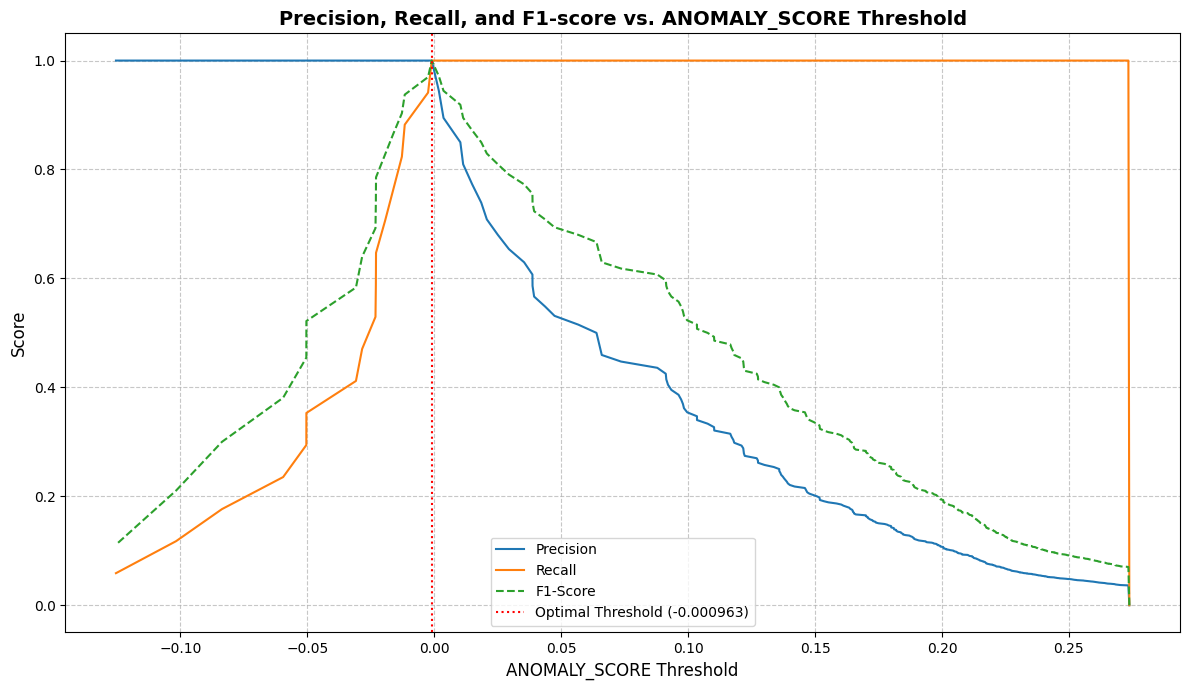

In [19]:
# Filter for active records
active_df_metrics = final_df[final_df['IS_ACTIVE'] == 1].copy()

# Ensure there are pseudo-fraud labels to evaluate against
if active_df_metrics['FRAUD_LABEL'].sum() == 0:
    print("No pseudo-fraud labels (FRAUD_LABEL = 1) found in active records. Cannot calculate optimal ANOMALY_SCORE threshold.")
else:
    threshold_metrics = []
    # Sort unique anomaly scores in descending order because lower scores are more anomalous
    unique_anomaly_scores = np.sort(active_df_metrics['ANOMALY_SCORE'].unique())[::-1]

    # Iterate through potential thresholds. Lower ANOMALY_SCORE indicates anomaly.
    for threshold in unique_anomaly_scores:
        # Predict anomalies based on the current threshold
        predictions = (active_df_metrics['ANOMALY_SCORE'] <= threshold).astype(int)

        # Calculate metrics if both classes are present in predictions and actuals
        if np.unique(predictions).size > 1 and np.unique(active_df_metrics['FRAUD_LABEL']).size > 1:
            precision, recall, fscore, _ = precision_recall_fscore_support(
                active_df_metrics['FRAUD_LABEL'], predictions, average='binary', pos_label=1, zero_division=0
            )
        else:
            # Handle cases where predictions or actuals don't have both classes
            precision = 0.0
            recall = 0.0
            fscore = 0.0

        threshold_metrics.append({'threshold': threshold, 'precision': precision, 'recall': recall, 'fscore': fscore})

    metrics_df_as = pd.DataFrame(threshold_metrics)

    # Find the threshold that maximizes F1-score
    optimal_as_threshold_row = metrics_df_as.loc[metrics_df_as['fscore'].idxmax()]
    optimal_as_threshold = optimal_as_threshold_row['threshold']

    print(f"Optimal ANOMALY_SCORE Threshold (max F1-score): {optimal_as_threshold:.6f}")
    print(f"  Precision at optimal threshold: {optimal_as_threshold_row['precision']:.2%}")
    print(f"  Recall at optimal threshold: {optimal_as_threshold_row['recall']:.2%}")
    print(f"  F1-score at optimal threshold: {optimal_as_threshold_row['fscore']:.2%}")

    # Plotting Precision, Recall, and F1-score against the threshold
    plt.figure(figsize=(12, 7))
    plt.plot(metrics_df_as['threshold'], metrics_df_as['precision'], label='Precision')
    plt.plot(metrics_df_as['threshold'], metrics_df_as['recall'], label='Recall')
    plt.plot(metrics_df_as['threshold'], metrics_df_as['fscore'], label='F1-Score', linestyle='--')
    plt.axvline(x=optimal_as_threshold, color='red', linestyle=':', label=f'Optimal Threshold ({optimal_as_threshold:.6f})')

    plt.title('Precision, Recall, and F1-score vs. ANOMALY_SCORE Threshold', fontsize=14, fontweight='bold')
    plt.xlabel('ANOMALY_SCORE Threshold', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
import joblib

print("[STEP 4.3] Executing Stratified Splits & Class-Imbalance Balancing...")

# Final feature checklist for supervised classification
xgb_features = [
    'MONTHLY_VALUE_ZSCORE', 'MONTHLY_MARKET_SHARE', 'NET_FLOW_VALUE',
    'INFLOW_AVG_VAL', 'OUTFLOW_AVG_VAL', 'IS_ACTIVE',
    'INSTITUTION_ENCODED', 'COMPANY_ENCODED', 'MONTH'
]

X = final_df[xgb_features]
y = final_df['FRAUD_LABEL']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42, stratify=y)

# Cost-sensitive weighting calculation to combat class imbalance
negative_instances = (y_train == 0).sum()
positive_instances = (y_train == 1).sum()
scale_weight_ratio = negative_instances / positive_instances

print(f"Total Training Samples: {X_train.shape[0]} | Testing Samples: {X_test.shape[0]}")
print(f"XGBoost scale_pos_weight assigned: {scale_weight_ratio:.2f}")

[STEP 4.3] Executing Stratified Splits & Class-Imbalance Balancing...
Total Training Samples: 3528 | Testing Samples: 1512
XGBoost scale_pos_weight assigned: 293.00


In [ ]:
# XGBOOST ENGINE TRAINING
xgb_model = XGBClassifier(
    n_estimators = 150,
    max_depth = 4,
    learning_rate =0.05,
    scale_pos_weight = scale_weight_ratio,
    eval_metric ='logloss',
    random_state = 42 )

xgb_model.fit(X_train,y_train)

# TARGETED PERFORMANCE ASSESSMENT MATRIX

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Mathematical computations for target metrics using sklearn functions
recall_val = recall_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
f1_val = f1_score(y_test, y_pred) # Calculate f1_score using the sklearn function
false_positive_rate = fp / (tn + fp) if (tn + fp) > 0 else 0

# Curves calculations for heavy imbalance evaluation
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc_score = auc(recall_vals, precision_vals)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Confusion Matrix Configurations:\n[[True Negatives (Compliant): {tn} | False Positives (False Alerts): {fp}]\n [False Negatives (Missed): {fn}      | True Positives (Caught Anom): {tp}]]\n")

print(f"1. RECALL (Sensitivity): {recall_val:.2%} -> [Ensures zero missed compliance breaches]")
print(f"2. PRECISION: {precision_val:.2%} -> [Ensures high accuracy / no wasted auditor time]")
print(f"3. F1-SCORE: {f1_val:.4f} -> [Harmonic mean of precision and recall]")
print(f"4. FALSE POSITIVE RATE (FPR): {false_positive_rate:.4%} -> [Measures low disruption to clean institutions]")
print(f"5. STANDARD ROC-AUC: {roc_auc:.4f} -> [Overall threshold ranking capability]")
print(f"6. TARGETED PR-AUC: {pr_auc_score:.4f} -> [True performance gauge for extreme imbalance cases]")
print("****************************************************************************************")
print(classification_report(y_test, y_pred, target_names=['Compliant Records (0)', 'Suspicious Anomalies (1)']))

Confusion Matrix Configurations:
[[True Negatives (Compliant): 1505 | False Positives (False Alerts): 2]
 [False Negatives (Missed): 0      | True Positives (Caught Anom): 5]]

1. RECALL (Sensitivity): 100.00% -> [Ensures zero missed compliance breaches]
2. PRECISION: 71.43% -> [Ensures high accuracy / no wasted auditor time]
3. F1-SCORE: 0.8333 -> [Harmonic mean of precision and recall]
4. FALSE POSITIVE RATE (FPR): 0.1327% -> [Measures low disruption to clean institutions]
5. STANDARD ROC-AUC: 0.9993 -> [Overall threshold ranking capability]
6. TARGETED PR-AUC: 0.8064 -> [True performance gauge for extreme imbalance cases]
****************************************************************************************
                          precision    recall  f1-score   support

   Compliant Records (0)       1.00      1.00      1.00      1507
Suspicious Anomalies (1)       0.71      1.00      0.83         5

                accuracy                           1.00      1512
            

In [ ]:
# DYNAMIC COMPLIANCE DETERMINANTS (FEATURE IMPORTANCES)

importances = pd.DataFrame({
    'Oversight Indicator Feature': xgb_features,
    'Risk Importance Weight': xgb_model.feature_importances_
}).sort_values(by='Risk Importance Weight', ascending=False)

print("\n--- Key Oversight Determinants (XGBoost Feature Importances) ---")
print(importances.to_string(index=False))


--- Key Oversight Determinants (XGBoost Feature Importances) ---
Oversight Indicator Feature  Risk Importance Weight
       MONTHLY_MARKET_SHARE                0.959482
            OUTFLOW_AVG_VAL                0.025818
             INFLOW_AVG_VAL                0.008910
             NET_FLOW_VALUE                0.003093
        INSTITUTION_ENCODED                0.001617
                      MONTH                0.000870
       MONTHLY_VALUE_ZSCORE                0.000211
                  IS_ACTIVE                0.000000
            COMPANY_ENCODED                0.000000


Generating Global SHAP Summary Plot...


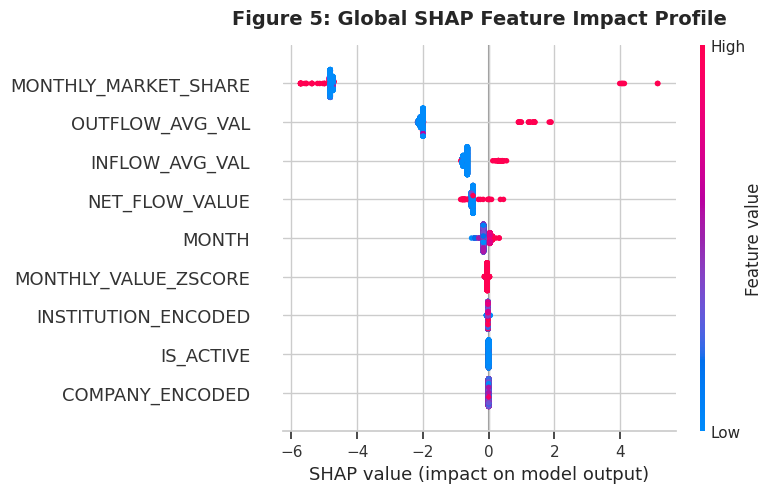

In [ ]:
import shap
# Initialize the Tree Explainer specifically optimized for tree ensembles like XGBoost
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(X_test)

# SHAP VISUALIZATION 1: GLOBAL FEATURE SUMMARY PLOT

print("Generating Global SHAP Summary Plot...")

plt.figure(figsize=(10, 6))
# The summary plot combines feature importance with feature effects
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Figure 5: Global SHAP Feature Impact Profile', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_global_summary.png', dpi=300)
plt.show()



Generating Local Explanatory Profile for a caught Anomaly...


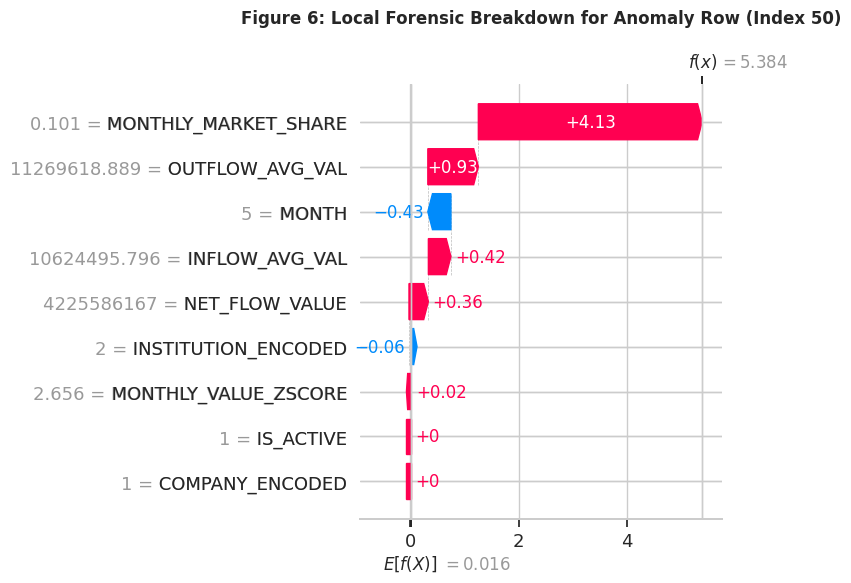

In [ ]:
# SHAP VISUALIZATION 2: LOCAL ANOMALY FORCE PLOT (EXPLAINING A CAUGHT FRAUD)

print("\nGenerating Local Explanatory Profile for a caught Anomaly...")

# Find indices where the model successfully caught a true anomaly (FRAUD_LABEL == 1)
anomaly_indices = np.where((y_test.values == 1) & (y_pred == 1))[0]

if len(anomaly_indices) > 0:
    # Pick the first caught anomaly case to explain
    target_anomaly_idx = anomaly_indices[0]

    plt.figure(figsize=(12, 4))
    # Generate a waterfall plot showing how features pushed the score from baseline to anomaly
    shap.plots.waterfall(shap_values[target_anomaly_idx], show=False)
    plt.title(f'Figure 6: Local Forensic Breakdown for Anomaly Row (Index {target_anomaly_idx})', fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('shap_local_anomaly_forensic.png', dpi=300)
    plt.show()
else:
    print("No true positive anomaly instances found in the test split to generate local breakdown.")

In [ ]:
# 1. Save the trained XGBoost model
joblib.dump(xgb_model, 'bot_fraud_classifier_model.pkl')

# 2. Save the categorical text encoders
joblib.dump(le_institution, 'institution_encoder.pkl')
joblib.dump(le_company, 'company_encoder.pkl')

print("All 3 deployment artifacts saved successfully!")

All 3 deployment artifacts saved successfully!


In [ ]:
import json
import os
import pandas as pd
from datetime import datetime, UTC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# PATH
metadata_dir = "/content/ml_models/"
metadata_path = os.path.join(metadata_dir, "model_metadata.json")
os.makedirs(metadata_dir, exist_ok=True)

# =========================
# METRICS
# =========================
# Ensure that y_test, y_pred, y_proba, tn, fp, fn, tp are defined from preceding cells (e.g., model training and evaluation cell).

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

false_positive_rate = fp / (fp + tn + 1e-9)

# =========================
# VERSION (IMPORTANT)
# =========================
version = f"v{datetime.now(UTC).strftime('%Y.%m.%d.%H%M%S')}"

file_path = "/content/ml_models/bot_fraud_classifier_model.pkl"

# =========================
# METADATA (BACKEND COMPATIBLE)
# =========================
metadata = {
    "model_version": version,
    "framework": "XGBoost Class-Imbalance Ensemble Classifier",
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc),
    "false_positive_rate": float(false_positive_rate),
    "trained_at": datetime.now(UTC).isoformat(),
    "file_path": file_path
}

registry_json = {
    "active_model": version,
    "versions": {
        version: metadata
    },
    "audit_log": []
}

# =========================
# SAVE
# =========================
with open(metadata_path, "w") as f:
    json.dump(registry_json, f, indent=2)

print("Saved metadata to:", metadata_path)
print("MODEL VERSION:", version)
print("RECALL:", recall)
print("PRECISION:", precision)
print("F1:", f1)
print("ROC_AUC:", roc_auc)
print("FPR:", false_positive_rate)

Saved metadata to: /content/ml_models/model_metadata.json
MODEL VERSION: v2026.06.26.224040
RECALL: 1.0
PRECISION: 0.7142857142857143
F1: 0.8333333333333334
ROC_AUC: 0.9993364299933644
FPR: 0.0013271400132705195
